# Actividad 1: Interpretabilidad y Diagnóstico de Modelos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import shap

pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42

## 1. Carga y exploración inicial

Cargamos el dataset y revisamos las columnas disponibles, tipos de datos y dimensiones.

In [2]:
df = pd.read_csv('data/ds_salaries.csv')
print(f"Dimensiones del dataset: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head()

Dimensiones del dataset: 3755 filas, 11 columnas


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           3755 non-null   int64
 1   experience_level    3755 non-null   str  
 2   employment_type     3755 non-null   str  
 3   job_title           3755 non-null   str  
 4   salary              3755 non-null   int64
 5   salary_currency     3755 non-null   str  
 6   salary_in_usd       3755 non-null   int64
 7   employee_residence  3755 non-null   str  
 8   remote_ratio        3755 non-null   int64
 9   company_location    3755 non-null   str  
 10  company_size        3755 non-null   str  
dtypes: int64(4), str(7)
memory usage: 322.8 KB


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
work_year,3755.0,NaN,NaN,NaN,2022.373635,0.691448,2020.0,2022.0,2022.0,2023.0,2023.0
experience_level,3755,4,SE,2516,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_type,3755,4,FT,3718,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_title,3755,93,Data Engineer,1040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary,3755.0,NaN,NaN,NaN,190695.571771,671676.500508,6000.0,100000.0,138000.0,180000.0,30400000.0
salary_currency,3755,20,USD,3224,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary_in_usd,3755.0,NaN,NaN,NaN,137570.38988,63055.625278,5132.0,95000.0,135000.0,175000.0,450000.0
employee_residence,3755,78,US,3004,NaN,NaN,NaN,NaN,NaN,NaN,NaN
remote_ratio,3755.0,NaN,NaN,NaN,46.271638,48.58905,0.0,0.0,0.0,100.0,100.0
company_location,3755,72,US,3040,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Entrenamiento del modelo inicial

In [5]:
target = 'salary_in_usd'
categorical_cols = [
    'experience_level', 'employment_type', 'job_title',
    'salary_currency', 'employee_residence', 'company_location', 'company_size'
]
numeric_cols = ['work_year', 'salary', 'remote_ratio']
features = categorical_cols + numeric_cols

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Muestras de entrenamiento: {X_train.shape[0]} | Muestras de test: {X_test.shape[0]}")

Muestras de entrenamiento: 3004 | Muestras de test: 751


In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
        ('num', 'passthrough', numeric_cols),
    ]
)

X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
X_train_df = pd.DataFrame(X_train_trans, columns=feature_names, index=X_train.index)
X_test_df = pd.DataFrame(X_test_trans, columns=feature_names, index=X_test.index)

print(f"Total de features luego del One-Hot Encoding: {X_train_df.shape[1]}")

Total de features luego del One-Hot Encoding: 260


In [7]:
rf_model = RandomForestRegressor(random_state=RANDOM_STATE)
rf_model.fit(X_train_df, y_train)

pred_train = rf_model.predict(X_train_df)
pred_test = rf_model.predict(X_test_df)

print("--- Evaluación en Train ---")
print(f"MAE : {mean_absolute_error(y_train, pred_train):,.2f}")
print(f"RMSE: {root_mean_squared_error(y_train, pred_train):,.2f}")
print(f"R²  : {r2_score(y_train, pred_train):.4f}")
print()
print("--- Evaluación en Test ---")
print(f"MAE : {mean_absolute_error(y_test, pred_test):,.2f}")
print(f"RMSE: {root_mean_squared_error(y_test, pred_test):,.2f}")
print(f"R²  : {r2_score(y_test, pred_test):.4f}")

--- Evaluación en Train ---
MAE : 659.03
RMSE: 4,793.66
R²  : 0.9942

--- Evaluación en Test ---
MAE : 1,248.34
RMSE: 8,148.56
R²  : 0.9832


El modelo inicial arroja un **R² de 0.983** en el conjunto de test con un MAE de apenas ~$1.248 USD. 

Para un problema de estimación salarial donde la variabilidad del mercado suele ser alta y las variables son mayormente categóricas (rol, país, seniority), un ajuste tan elevado resulta sumamente llamativo. Da la pauta de que el modelo podría estar apoyándose en alguna variable que revela directa o indirectamente el target.

## 3. Diagnóstico Global con PFI (Permutation Feature Importance)

In [8]:
def consolidar_pfi_ohe(importancias, nombres_features, cols_categoricas):
    """Suma las importancias de las columnas dummy pertenecientes a la misma variable categórica."""
    agrupado = {}
    for feat, imp in zip(nombres_features, importancias):
        var_origen = feat.replace('num__', '')
        for cat in cols_categoricas:
            if feat.startswith(f'cat__{cat}_'):
                var_origen = cat
                break
        agrupado[var_origen] = agrupado.get(var_origen, 0.0) + imp
    return pd.Series(agrupado).sort_values(ascending=False)

# Cálculo de PFI sobre test
pfi_res = permutation_importance(
    rf_model, X_test_df, y_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)

pfi_global = consolidar_pfi_ohe(pfi_res.importances_mean, feature_names, categorical_cols)
pfi_global

salary                1.912932
salary_currency       0.263761
employee_residence    0.001033
company_location      0.000895
work_year             0.000412
job_title             0.000372
company_size          0.000352
experience_level      0.000097
employment_type       0.000027
remote_ratio         -0.000063
dtype: float64

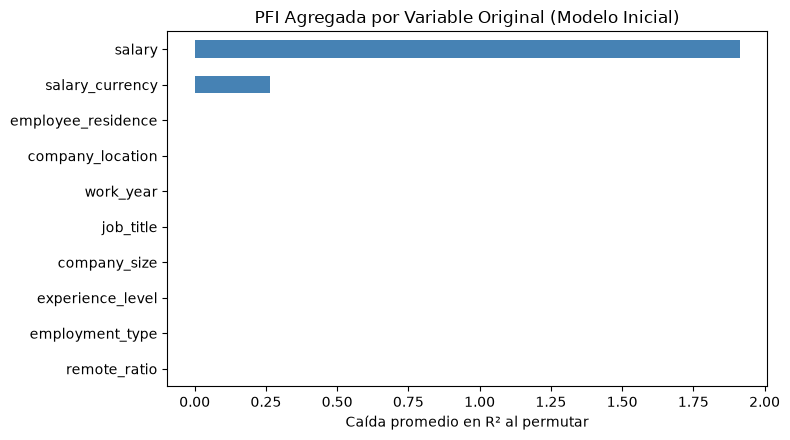

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
pfi_global.sort_values().plot.barh(ax=ax, color='steelblue')
ax.set_title('PFI Agregada por Variable Original (Modelo Inicial)')
ax.set_xlabel('Caída promedio en R² al permutar')
plt.tight_layout()
plt.show()


- La columna **`salary`** explica prácticamente toda la capacidad predictiva del modelo (caída de R² de ~1.91 al permutar).
- La segunda variable es **`salary_currency`** (~0.26).
- El resto de los atributos (`job_title`, `experience_level`, `employee_residence`, `company_size`, etc.) tienen un peso cercano a 0 (del orden de 0.001 o menos).

el árbol ignora casi por completo los atributos laborales reales y se concentra exclusivamente en `salary` y su moneda, lo que sugiere un caso claro de *data leakage*.

## 4. Diagnóstico Local con SHAP

Para inspeccionar el comportamiento a nivel individual, utilizamos `TreeExplainer` de SHAP y seleccionamos dos observaciones con predicciones opuestas en el conjunto de test: una con el salario predicho más alto y otra con el más bajo.

In [10]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_test_df)

idx_alta = int(np.argmax(pred_test))
idx_baja = int(np.argmin(pred_test))

print(f"Predicción más alta: índice {idx_alta} -> Pred: ${pred_test[idx_alta]:,.2f} | Real: ${y_test.iloc[idx_alta]:,.2f}")
print(f"Predicción más baja : índice {idx_baja} -> Pred: ${pred_test[idx_baja]:,.2f} | Real: ${y_test.iloc[idx_baja]:,.2f}")

Predicción más alta: índice 513 -> Pred: $379,113.61 | Real: $375,000.00
Predicción más baja : índice 538 -> Pred: $7,697.22 | Real: $7,000.00


Datos del perfil con predicción alta:
job_title             Data Science Tech Lead
experience_level                          SE
salary                                375000
salary_currency                          USD
employee_residence                        US
Name: 2359, dtype: object


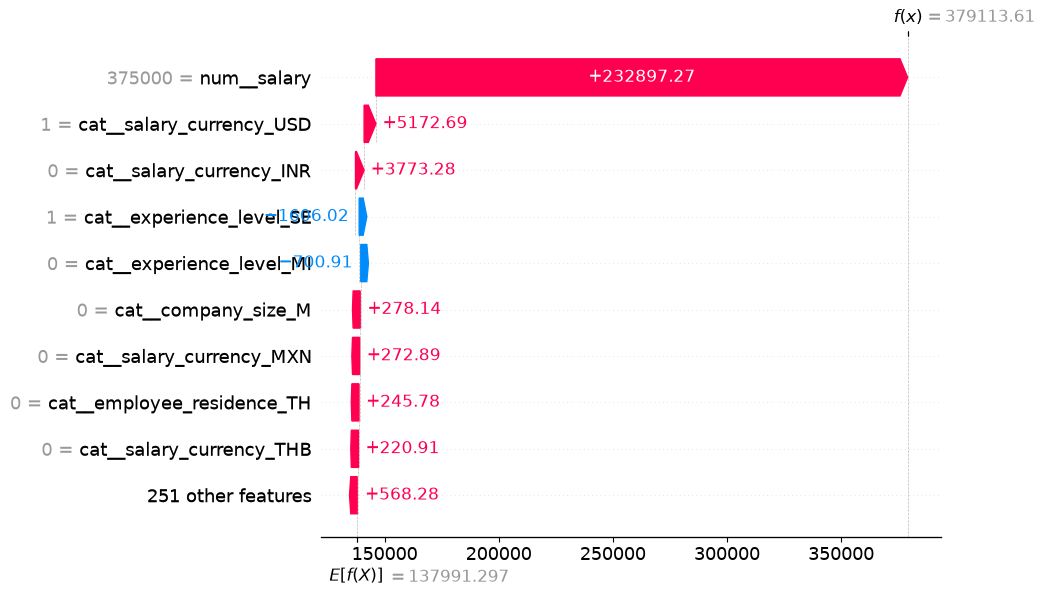

In [11]:
print("Datos del perfil con predicción alta:")
print(X_test.iloc[idx_alta][['job_title', 'experience_level', 'salary', 'salary_currency', 'employee_residence']])

shap.plots.waterfall(shap_values[idx_alta], max_display=10)

**Caso 1 (predicción alta):** 
Para esta observación (`Data Science Tech Lead` con salario registrado de $375.000 USD), el valor base del modelo parte de ~$138.000 USD. El gráfico waterfall muestra que prácticamente todo el salto hacia arriba (+ $232.897) lo genera la variable `salary`. Las demás características (como el nivel de experiencia o el puesto) aportan valores mínimos en comparación.

Datos del perfil con predicción baja:
job_title             Autonomous Vehicle Technician
experience_level                                 EN
salary                                         7000
salary_currency                                 USD
employee_residence                               GH
Name: 573, dtype: object


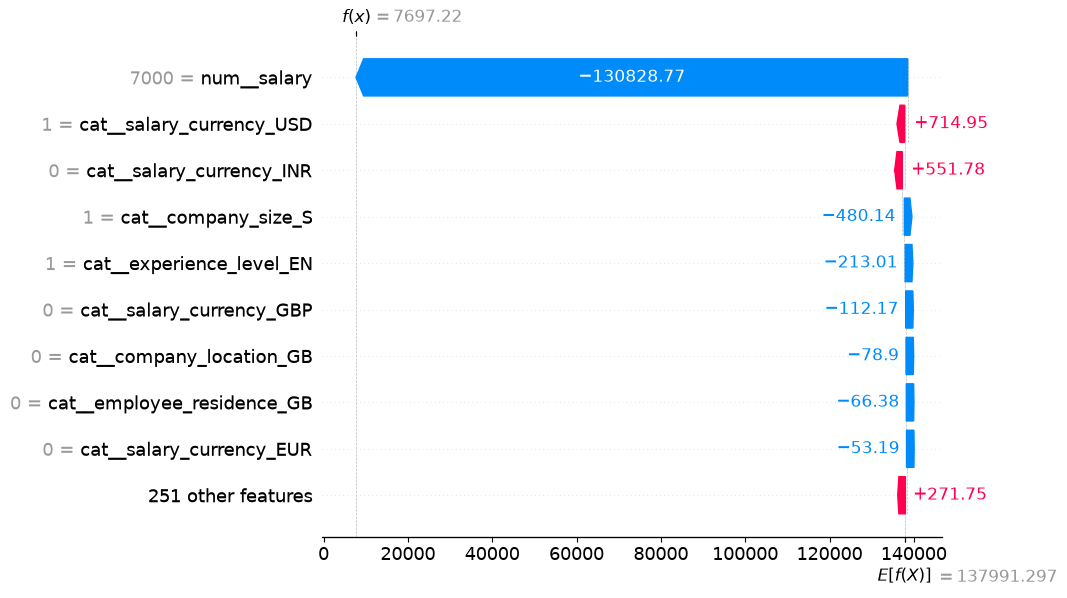

In [12]:
print("Datos del perfil con predicción baja:")
print(X_test.iloc[idx_baja][['job_title', 'experience_level', 'salary', 'salary_currency', 'employee_residence']])

shap.plots.waterfall(shap_values[idx_baja], max_display=10)

**Caso 2 (predicción baja):** 
En el caso opuesto (`Autonomous Vehicle Technician`, junior, con salario de 7.000 USD), ocurre exactamente lo mismo pero en sentido descendente: `salary` empuja la predicción hacia abajo en -$130.829 respecto al valor base.

Ambos diagnósticos locales son 100% coherentes con el PFI global: el modelo no está asociando combinaciones de seniority, país o puesto, sino ajustando directamente en función del número presente en la columna `salary`.

## 5. Auditoría del modelo

### 5.1 Verificación empírica del Data Leakage
La hipótesis es que `salary_in_usd` proviene de aplicar una conversión fija a `salary` según la moneda y el año de registro.

In [13]:
# 1. En filas cuya moneda ya es USD, salary y salary_in_usd deben ser idénticos
usd_mask = df['salary_currency'] == 'USD'
print(f"Proporción de filas en USD: {usd_mask.mean():.1%}")
print(f"Coincidencia exacta (salary == salary_in_usd) en USD: {(df.loc[usd_mask, 'salary'] == df.loc[usd_mask, 'salary_in_usd']).mean():.1%}")

# 2. Para otras monedas, calculamos el ratio salary_in_usd / salary agrupado por moneda y año
df_non_usd = df[~usd_mask].copy()
df_non_usd['conversion_ratio'] = df_non_usd['salary_in_usd'] / df_non_usd['salary']

ratios = df_non_usd.groupby(['salary_currency', 'work_year'])['conversion_ratio'].agg(['count', 'mean', 'std'])
ratios.sort_values(by='count', ascending=False).head(10)

Proporción de filas en USD: 85.9%
Coincidencia exacta (salary == salary_in_usd) en USD: 100.0%


count      mean           std
salary_currency work_year                               
EUR             2022         115  1.050662  5.002365e-06
GBP             2022          83  1.231328  5.564395e-06
                2023          62  1.215226  6.183916e-06
EUR             2023          53  1.073085  6.328765e-06
                2021          44  1.182046  1.459011e-05
                2020          24  1.140463  1.035608e-05
INR             2021          23  0.013523  5.477232e-07
                2022          20  0.012718  2.895691e-07
GBP             2021          13  1.375461  5.685603e-06
INR             2023          11  0.012159  2.234056e-07

Como se observa en la tabla, la desviación estándar del ratio de conversión para cada par `(salary_currency, work_year)` es prácticamente 0. 

Esto demuestra que **`salary_in_usd` es una transformación matemática directa de `salary`, `salary_currency` y `work_year`**. Al incluir `salary` como predictor, le dimos al modelo la respuesta casi exacta mediante una simple tasa de cambio.

In [14]:
# Verificamos concordancia entre residencia del empleado y ubicación de la empresa
coincidencia_geo = (df['employee_residence'] == df['company_location']).mean()
print(f"Porcentaje de coincidencia entre employee_residence y company_location: {coincidencia_geo:.2%}")

Porcentaje de coincidencia entre employee_residence y company_location: 97.44%


### 5.2 Redundancia geográfica y alta cardinalidad

Otros dos aspectos a considerar en la auditoría:
1. **Redundancia geográfica:** En el **97.4%** de los registros, el país del empleado coincide con el país de la empresa. Al incluir ambas, la importancia del factor geográfico se reparte entre las dos columnas correlacionadas.
2. **Cardinalidad de `job_title`:** Existen 93 títulos de trabajo distintos en el dataset, lo que genera muchas columnas dummy dispersas con pocas observaciones cada una tras el One-Hot Encoding.

## 6. Corrección (Modelo v2) y Comparación

Para corregir el *data leakage*, eliminamos la columna `salary` del conjunto de entrenamiento. 

*Nota:* Conservamos `salary_currency` ya que, sin la columna `salary`, la moneda no permite reconstruir el target numérico y puede funcionar legítimamente como un proxy del mercado económico en el que se paga el sueldo.

In [15]:
# Variables sin la columna problemática
features_v2 = [c for c in features if c != 'salary']
numeric_cols_v2 = [c for c in numeric_cols if c != 'salary']
categorical_cols_v2 = categorical_cols

X2 = df[features_v2]
y2 = df[target]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=RANDOM_STATE
)

preprocessor_v2 = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols_v2),
        ('num', 'passthrough', numeric_cols_v2),
    ]
)

X2_train_trans = preprocessor_v2.fit_transform(X2_train)
X2_test_trans = preprocessor_v2.transform(X2_test)

feature_names_v2 = preprocessor_v2.get_feature_names_out()
X2_train_df = pd.DataFrame(X2_train_trans, columns=feature_names_v2, index=X2_train.index)
X2_test_df = pd.DataFrame(X2_test_trans, columns=feature_names_v2, index=X2_test.index)

# Entrenamiento modelo v2
rf_v2 = RandomForestRegressor(random_state=RANDOM_STATE)
rf_v2.fit(X2_train_df, y2_train)

pred2_train = rf_v2.predict(X2_train_df)
pred2_test = rf_v2.predict(X2_test_df)

print("--- Modelo v2 (sin leakage) — Test ---")
print(f"MAE : {mean_absolute_error(y2_test, pred2_test):,.2f}")
print(f"RMSE: {root_mean_squared_error(y2_test, pred2_test):,.2f}")
print(f"R²  : {r2_score(y2_test, pred2_test):.4f}")

--- Modelo v2 (sin leakage) — Test ---
MAE : 36,527.09
RMSE: 48,783.19
R²  : 0.3972


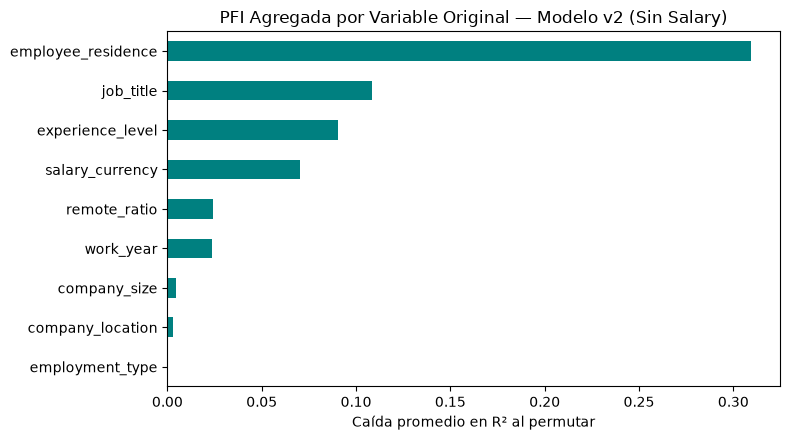

In [16]:
pfi_res_v2 = permutation_importance(
    rf_v2, X2_test_df, y2_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)

pfi_v2 = consolidar_pfi_ohe(pfi_res_v2.importances_mean, feature_names_v2, categorical_cols_v2)

fig, ax = plt.subplots(figsize=(8, 4.5))
pfi_v2.sort_values().plot.barh(ax=ax, color='teal')
ax.set_title('PFI Agregada por Variable Original — Modelo v2 (Sin Salary)')
ax.set_xlabel('Caída promedio en R² al permutar')
plt.tight_layout()
plt.show()

## 7. Comparación y Conclusiones

Al comparar el modelo original con el modelo corregido:

1. **Rendimiento métrico:** En el modelo v2, el $R^2$ en test cae de **0.983** a **0.397**, y el MAE pasa de ~$1.248 USD a ~$36.527 USD. Esta disminución en las métricas es totalmente esperable: el modelo original no estaba prediciendo salarios sino aplicando una fórmula de conversión, mientras que el modelo v2 debe inferir el salario a partir de patrones laborales reales mucho más ruidosos.
2. **Distribución de importancia:** En el nuevo ranking de PFI, la importancia se redistribuye de forma natural entre los determinantes reales del mercado:
   - **`employee_residence`** pasa a ser la variable más relevante (~0.31).
   - Le siguen **`job_title`** (~0.11) y **`experience_level`** (~0.09).
   - **`salary_currency`** conserva cierto peso (~0.07), operando como proxy de la región geográfica.
   - **`company_location`** queda con peso casi nulo (~0.003), lo que refleja la redundancia con `employee_residence`.
3. **Razonabilidad del modelo:** Aunque el modelo v2 tiene menor puntuación teórica, resulta mejor para las predicciones conociendo su potencial error. Permite evaluar de manera coherente el impacto del seniority, el rol y la ubicación geográfica en la remuneración en dólares.